In [1]:
import scqubits
import qutip
import numpy as np
import matplotlib.pyplot as plt

In [2]:
EJ = 6.86
EC = 1.46
EL = 0.23
qubit_level = 5
osc_level = 3
g = 0.1
qbt = scqubits.Fluxonium(EJ=EJ,EC=EC,EL=EL,flux=0,cutoff=110,truncated_dim=qubit_level)
evals = qbt.eigenvals()

osc = scqubits.Oscillator(E_osc=evals[3]-evals[0],truncated_dim=osc_level)
hilbertspace = scqubits.HilbertSpace([qbt, osc])
hilbertspace.add_interaction(g_strength=g,op1=qbt.n_operator,op2=osc.creation_operator,add_hc=True)
hilbertspace.generate_lookup()



In [3]:
evals[3]-evals[0]

7.294189741417967

In [4]:
def get_dressed_state_overlaps(hamiltonian, product_index):
    """
    For a given product state index, finds the dressed states with decreasing overlap and the corresponding overlaps.
    
    Parameters:
    - H_with_interaction_no_drive: Hamiltonian in the product basis of a coupled system.
    - product_index: Index of the product state for which overlaps are calculated.
    
    Returns:
    - dressed_indices: Indices of the dressed states ordered by decreasing overlap with the product state.
    - overlaps: Overlaps of the dressed states with the product state.
    """
    # Compute eigenstates of the Hamiltonian
    evals, evecs = hamiltonian.eigenstates()
    overlap_matrix = scqubits.utils.spectrum_utils.convert_evecs_to_ndarray(evecs)

    # Extract overlaps for the specified product state with all dressed states
    overlaps_with_product_state = np.abs(overlap_matrix[:, product_index])
    
    # Sort the dressed states by decreasing overlap with the product state
    sorted_indices = np.argsort(overlaps_with_product_state)[::-1]  # Indices of dressed states sorted by overlap
    sorted_overlaps = overlaps_with_product_state[sorted_indices]  # Sorted overlaps
    
    return list(sorted_indices), list(sorted_overlaps)

In [5]:
top_dressed_states, overlaps = get_dressed_state_overlaps(hamiltonian = hilbertspace.hamiltonian(),
                           product_index = 0 * osc_level + 1)
top_dressed_states[:2], overlaps[:2]

([3, 4], [0.707533033457218, 0.7066576869522642])

In [6]:
top_dressed_states, overlaps = get_dressed_state_overlaps(hamiltonian = hilbertspace.hamiltonian(),
                           product_index = 3 * osc_level + 0)
top_dressed_states[:2], overlaps[:2]

([4, 3], [0.7075328866454905, 0.7066576032129069])

In [7]:
(evals,) = hilbertspace["evals"]
diag_dressed_hamiltonian = qutip.Qobj((
                2 * np.pi * qutip.Qobj(np.diag(evals),
                dims=[hilbertspace.subsystem_dims] * 2)
        )[:, :])

a = qutip.Qobj(hilbertspace.op_in_dressed_eigenbasis(osc.annihilation_operator)[:, :])

kappa = 3e-2
c_ops = [np.sqrt(kappa) * a]


# LRU simulation

In [8]:

tlist = np.linspace(0,500,100)

 Total run time:   8.55s*] Elapsed 8.55s / Remaining 00:00:00:00[*********54%           ] Elapsed 4.58s / Remaining 00:00:00:03


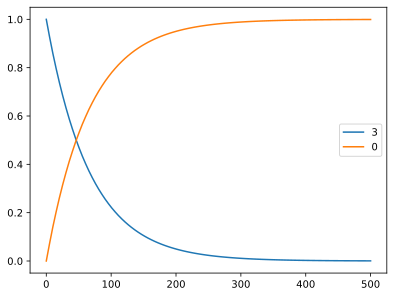

In [9]:

result = qutip.mesolve(
        H=[diag_dressed_hamiltonian],
        rho0=qutip.basis(qubit_level*osc_level,3),
        tlist=tlist,
        c_ops=c_ops,
        e_ops = [
            qutip.basis(qubit_level*osc_level,3)*qutip.basis(qubit_level*osc_level,3).dag(),
            qutip.basis(qubit_level*osc_level,0)*qutip.basis(qubit_level*osc_level,0).dag()
        ],
        args = {'w_d': 0.1, 'amp': 0},
        options=qutip.Options(store_states=False, nsteps=8000, num_cpus=1),
        progress_bar = qutip.ui.progressbar.EnhancedTextProgressBar(),
    )

plt.plot(tlist,result.expect[0],label='3')
plt.plot(tlist,result.expect[1],label='0')
plt.legend()

# qubit readout

In [10]:
EJ = 6.86
EC = 1.46
EL = 0.23
qubit_level = 5
osc_level = 20
g = 0.1
qbt = scqubits.Fluxonium(EJ=EJ,EC=EC,EL=EL,flux=0,cutoff=110,truncated_dim=qubit_level)
evals = qbt.eigenvals()

osc = scqubits.Oscillator(E_osc=evals[3]-evals[0],truncated_dim=osc_level)
hilbertspace = scqubits.HilbertSpace([qbt, osc])
hilbertspace.add_interaction(g_strength=g,op1=qbt.n_operator,op2=osc.creation_operator,add_hc=True)
hilbertspace.generate_lookup()

(evals,) = hilbertspace["evals"]
diag_dressed_hamiltonian = qutip.Qobj((
                2 * np.pi * qutip.Qobj(np.diag(evals),
                dims=[hilbertspace.subsystem_dims] * 2)
        )[:, :])

a = qutip.Qobj(hilbertspace.op_in_dressed_eigenbasis(osc.annihilation_operator)[:, :])


def square_cos(t, args):
    w_d = args['w_d']
    amp = args['amp']
    t_stop = args.get('t_stop', None)
    if t_stop != None:
        if t <= t_stop:
            cos = np.cos(w_d * 2 * np.pi * t)
            return 2 * np.pi * amp * cos
        else:
            return 0
    else:
        cos = np.cos(w_d * 2 * np.pi * t)
        return 2 * np.pi * amp * cos
    

H_with_drive = [
    diag_dressed_hamiltonian,
    [a+a.dag(), square_cos],
]

kappa = 3e-2
c_ops = [np.sqrt(kappa) * a]


In [11]:
import math
def generate_single_mapping(H_with_interaction_no_drive) -> np.ndarray:
    """
    The input should be in product basis
    Maps product of bare states to dressed state
    Returns a dictionary like {(0,0,0):0,(0,0,1):1}
    Use this function instead of scqubit's because I can change the overlap threshold here
    """
    evals, evecs = H_with_interaction_no_drive.eigenstates()
    overlap_matrix = scqubits.utils.spectrum_utils.convert_evecs_to_ndarray(evecs)
    OVERLAP_THRESHOLD = 0.1
    product_state_names = []
    dims = H_with_interaction_no_drive.dims[0]
    system_size = len(dims)
    def generate_product_states(current_state, ele_index):
        if ele_index == system_size:
            product_state_names.append(tuple(current_state))
            return
        
        for l in range(dims[ele_index]):
            current_state[ele_index] = l
            generate_product_states(current_state.copy(), ele_index + 1)

    current_state = [0] * system_size
    generate_product_states(current_state, 0)

    total_dim = math.prod(dims)
    dressed_indices_of_product_states = [None] * total_dim

    # for every energy eigenstate, from the lowerst to the highest, find the product state
    for dressed_index in range(len(evals)):
        max_position = (np.abs(overlap_matrix[dressed_index, :])).argmax()
        max_overlap = np.abs(overlap_matrix[dressed_index, max_position])
        overlap_matrix[:, max_position] = 0
        dressed_indices_of_product_states[int(max_position)] = dressed_index
        if (max_overlap**2 < OVERLAP_THRESHOLD):
            print(f'max overlap^2 {max_overlap**2} below threshold for dressed state {dressed_index} with eval {evals[dressed_index]}')
    product_to_dressed = {}
    for product, dressed in zip(product_state_names,dressed_indices_of_product_states):
        product_to_dressed[product] = dressed
    return product_to_dressed

product_to_dressed = generate_single_mapping(hilbertspace.hamiltonian())
energies=  hilbertspace.eigenvals(qubit_level * osc_level)

def dressed_ener(ql,ol):
    return energies[product_to_dressed[(ql,ol)]]
def print_stats():
    print(f"qbt freq at osc {0}:\t{(dressed_ener(1,0)-dressed_ener(0,0))}")
    ground_freq = dressed_ener(1,0)-dressed_ener(0,0)
    for i in range(1,osc_level-1):
        freq = dressed_ener(1,i)-dressed_ener(0,i)
        print(f"qbt freq at osc {i}:\t{freq:.5f}, \tdiff to at osc ground {freq - ground_freq:.5f}, {abs(freq - ground_freq)/ground_freq*100:.4f}% diff")

    print(f"\noscillator freq at qubit level:\t0 \t 1 :")
    print(f"oscillator transition 0-1: \t{dressed_ener(0,1)-dressed_ener(0,0):.5f}\t{dressed_ener(1,1)-dressed_ener(1,0):.5f}")
    for i in range(1,osc_level-1):
        print(f"oscillator transition {i}-{i+1}: \t{dressed_ener(0,i+1)-dressed_ener(0,i):.5f}\t{dressed_ener(1,i+1)-dressed_ener(1,i):.5f} non-linearity: {(dressed_ener(0,i+1)-dressed_ener(0,i))  -(dressed_ener(0,1)-dressed_ener(0,0))}")

    print(f"")
    print(f"10-11: {(dressed_ener(1,1)-dressed_ener(1,0)):.4f}, diff to 00-01: {abs((dressed_ener(0,1)-dressed_ener(0,0))    -(dressed_ener(1,1)-dressed_ener(1,0)))}")
print_stats()


qbt freq at osc 0:	4.3010991939896615
qbt freq at osc 1:	4.35792, 	diff to at osc ground 0.05682, 1.3210% diff
qbt freq at osc 2:	4.38249, 	diff to at osc ground 0.08139, 1.8922% diff
qbt freq at osc 3:	4.40179, 	diff to at osc ground 0.10069, 2.3410% diff
qbt freq at osc 4:	4.41835, 	diff to at osc ground 0.11726, 2.7262% diff
qbt freq at osc 5:	4.43317, 	diff to at osc ground 0.13207, 3.0706% diff
qbt freq at osc 6:	4.44673, 	diff to at osc ground 0.14564, 3.3860% diff
qbt freq at osc 7:	4.45935, 	diff to at osc ground 0.15825, 3.6793% diff
qbt freq at osc 8:	4.47121, 	diff to at osc ground 0.17011, 3.9551% diff
qbt freq at osc 9:	4.48245, 	diff to at osc ground 0.18135, 4.2164% diff
qbt freq at osc 10:	4.49317, 	diff to at osc ground 0.19207, 4.4656% diff
qbt freq at osc 11:	4.50344, 	diff to at osc ground 0.20235, 4.7045% diff
qbt freq at osc 12:	4.51333, 	diff to at osc ground 0.21223, 4.9344% diff
qbt freq at osc 13:	4.52287, 	diff to at osc ground 0.22178, 5.1562% diff
qbt freq 

In [12]:

tlist = np.linspace(0,500,500)
w_d = 7.29640
results = []
for i in [0,1]:
    results.append(qutip.mesolve(
        H=H_with_drive,
        rho0=qutip.basis(qubit_level*osc_level,i),
        tlist=tlist,
        e_ops = [
            a
        ],
        c_ops = c_ops,
        args = {'w_d': w_d, 'amp': 3e-2},
        options=qutip.Options(store_states=False, nsteps=10000, num_cpus=1),
        progress_bar = qutip.ui.progressbar.EnhancedTextProgressBar(),
    ))

 [          1%           ] Elapsed 150.57s / Remaining 00:04:08:26

Traceback (most recent call last):
capi_return is NULL
Call-back cb_f_in_zvode__user__routines failed.
Fatal Python error: F2PySwapThreadLocalCallbackPtr: F2PySwapThreadLocalCallbackPtr: PyLong_AsVoidPtr failed
Python runtime state: initialized
  File "qutip/cy/cqobjevo.pyx", line 212, in qutip.cy.cqobjevo.CQobjEvo.mul_vec
  File "qutip/cy/cqobjevo.pyx", line 679, in qutip.cy.cqobjevo.CQobjEvoTd._mul_vec
  File "qutip/cy/cqobjevo.pyx", line 293, in qutip.cy.cqobjevo.CQobjEvo._factor_dyn
  File "qutip/cy/cqobjevo.pyx", line 278, in qutip.cy.cqobjevo.CQobjEvo._factor
  File "/Users/jiakaiwang/opt/miniconda3/envs/tensorflow/lib/python3.10/site-packages/qutip/qobjevo.py", line 1820, in __call__
    def __call__(self, t, args={}):
KeyboardInterrupt

Extension modules: zmq.backend.cython.context, zmq.backend.cython.message, zmq.backend.cython.socket

: 

In [ ]:
def find_dominant_frequency(expectation,tlist,dominant_frequency_already_found = None,plot = False,plot_freq = False):
    # In case alpha oscillates not at drive frequency, we do fourier transform to make the plot of coherent state look better 

    if dominant_frequency_already_found != None:
        expectation = expectation * np.exp(-1j*2*np.pi*dominant_frequency_already_found*tlist)

    expectation_fft = np.fft.fft(expectation)
    frequencies = np.fft.fftfreq(len(tlist), d=(tlist[1] - tlist[0]))  # assuming tlist is uniformly spaced

    # Identify the dominant frequency: 
    # (we exclude the zero frequency, which usually has the DC offset)
    dominant_freq_idx = np.argmax(np.abs(expectation_fft[1:])) + 1
    dominant_freq = frequencies[dominant_freq_idx]

    if plot:
        # Print the dominant frequency
        print(f"The dominant oscillation frequency is: {dominant_freq:.3f} (in the same units as 1/timestep)")

        fft_shifted = np.fft.fftshift(expectation_fft)
        frequencies_shifted = np.fft.fftshift(frequencies)
        plt.plot(frequencies_shifted, np.abs(fft_shifted))
        plt.xlabel('Frequency (arbitrary units)')
        plt.ylabel('Magnitude')
        plt.title('FFT of the Expectation Value')
        plt.grid(True)
        plt.show()
    elif plot_freq:
        plt(expectation_fft)
        plt.show()
    else:
        return dominant_freq
    
    
first_dominant_freq =find_dominant_frequency(results[1].expect[0],tlist)


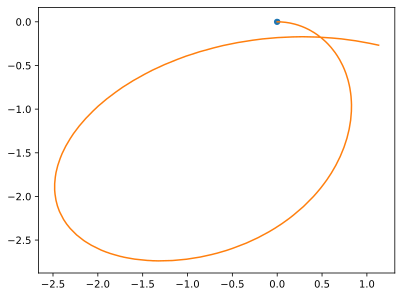

In [ ]:
for i in [0,1]:
    alpha = results[i].expect[0]*np.exp(-1j * 2 * np.pi * first_dominant_freq * tlist)
    plt.plot(-alpha.imag,alpha.real,label = rf'$\left|{i}\right>$')
